In [3]:
# To run cells in this notebook, update the location of the MVTec dataset in the variable below

data_location = '/home/suzy/datascientest/anomalie_proj/datasets/MVTec'


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Projet Datascientest
## Détection d'anomalies dans des pièces industrielles

L’objectif de ce projet est de développer un modèle capable de détecter une anomalie sur une pièce industrielle à l’aide d’une image. Pour cela, il est possible d’utiliser un réseau de neurones convolutif (CNN) ou toute autre architecture adaptée à ce type de problématique. Plusieurs approches sont envisageables pour ce projet, avec un apprentissage supervisé ou non supervisé. Un premier objectif est d’effectuer une classification binaire sur les images des jeux de données, pour isoler les images présentant une anomalie. Un second objectif est d’identifier l’anomalie détectée, transformant ainsi le problème en classification multi-classes. Chaque pièce est associée à une série d’anomalies qui lui sont propres.

### Objectifs
1. Detection d'anomalies dans les images (classification binaire)
2. Classification (multi-class) d'anomalie détectée
3. Création d'un application Streamlit avec le modèle final

## Datasets

### 1. MVTec
**url:** https://www.mvtec.com/company/research/datasets/mvtec-ad

**Description:** Dataset for benchmarking anomaly detection methods with a focus on industrial inspection. It contains over 5000 high-resolution images divided into fifteen different object and texture categories. Each category comprises a set of defect-free training images and a test set of images with various kinds of defects as well as images without defects.

**Dataset size:** over 5000 high-resolution images

**Definition of anomalies for dataset:** Pixel-precise annotations of all anomalies are provided.

**Categories of object:**
- Bottle
- Cable
- Capsule
- Carpet
- Grid
- Hazelnut
- Leather
- Metal Nut
- Pill
- Screw
- Tile
- Toothbrush
- Transistor
- Wood
- Zipper

### 2. RAD
**url:** https://github.com/hustCYQ/RAD-dataset

**Description:** Robust Anomaly Detection (RAD) dataset with free views, uneven illuminations, and blurry collections to systematically evaluate the robustness of current anomaly detection methods.

**Definition of anomalies for dataset:** Normal scenarios depict a work platform with multiple metal holes, whereas the abnormal scenarios feature the work platform with foreign objects. To establish a comprehensive benchmark for anomaly detection robustness, we introduce different types of foreign objects onto the work platform, including bolts, cable ties, sponges, and tapes. Subsequently, the images are captured under various imaging noises, encompassing random viewpoints, illuminations, and imaging distances to replicate practical noise scenarios.

**Dataset size:** 286 normal samples, of which 213 are used for training, and the remaining 73 for testing. Additionally, 327, 293, 281, and 323 abnormal samples across the four categories are used for testing.

**Categories:**
- Bolt
- Ribbon
- Sponge
- Tape


> **Note:** Images presentant des anomalies sont présent seulement dans les sets de 'test' pour les deux datasets

In [4]:
# Libraries import

import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random
from pathlib import Path


In [5]:
# Functions

def display_img(img_path:str, img:str = 'random', print_info:bool = True) -> str:
    img_list = os.listdir(img_path)
    if img == 'random':
        img_file = random.choice(img_list)
    else:
        if img in img_list:
            img_file = img
        else:
            raise IOError(f"File {img} not found in directory {img_path}")

    img_array = cv2.imread(os.path.join(img_path, img_file), cv2.IMREAD_COLOR)
    if print_info:
        print(f'Image randomly chosen: {img_file}')
        print(f"Size of image: {img_array.shape}")
    plt.imshow(img_array)
    plt.show()
    return img_file



def count_img_categories(filepath: str, filetype: str) -> dict:

    p = Path(filepath)
    files_dict = {}
    for subdir in p.iterdir():
        if subdir.is_dir():
            files = subdir.rglob(f"*.{filetype}")
            filecount = 0
            for f in files:
                filecount += 1
            files_dict[subdir.name] = filecount

    return files_dict


def plot_masks_and_ratios(obj, mask_path):
    mask_list = os.listdir(mask_path)
    mask_file = random.choice(mask_list)
    mask = cv2.imread(os.path.join(mask_path, mask_file), cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(12, 12))
    i = 1
    for file in mask_list:
        mask = cv2.imread(os.path.join(mask_path, file), cv2.IMREAD_GRAYSCALE)
        plt.subplot((len(mask_list)//3), 3, i)
        plt.title(f"Mask area ratio: {round(np.count_nonzero(mask) / (mask.shape[0]*mask.shape[1]), 4)}")
        plt.imshow(mask)
        i += 1
    plt.show()


def plot_all_defect_ratios(obj: str, boxplot: bool = False) -> None:
    obj_path = f"{data_location}/{obj}/ground_truth"
    anomalie_list = os.listdir(obj_path)

    plt.figure(figsize=(10, 8))
    i = 1
    for defect in anomalie_list:
        mask_path = os.path.join(obj_path, defect)
        mask_list = os.listdir(mask_path)
    
        mask_ratios = []
        for file in mask_list:
            mask = cv2.imread(os.path.join(mask_path, file), cv2.IMREAD_GRAYSCALE)
            mask_ratios.append(round(np.count_nonzero(mask) / (mask.shape[0]*mask.shape[1]), 4))
        plt.subplot((len(anomalie_list)//2), 2, i)
        plt.title(f"Mask ratios for {obj} {defect} anomalie")
        if boxplot:
            plt.boxplot(mask_ratios)
        else:
            plt.bar(mask_list, mask_ratios)
        plt.xticks(rotation=90)
        i += 1

    plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.4, hspace=0.6)
    plt.show()
    

def check_for_duplicate_images(obj: str, dataset: str) -> list:
    '''
    Print filenames of any duplicate images found.
    arg dataset is train or test
    '''
    cat_path = f"{data_location}/{obj}/{dataset}"
    dir_list = os.listdir(cat_path)

    all_imgs = []
    for cat in dir_list:
        img_path = os.path.join(cat_path, cat)
        img_list = os.listdir(img_path)
    
        for imgfile in img_list:
            img = cv2.imread(os.path.join(img_path, imgfile), cv2.IMREAD_GRAYSCALE)
            #print(img.shape)
            all_imgs.append(img)

    imgs_stacked_3D = np.dstack(all_imgs)
    shape_all = imgs_stacked_3D.shape
    unique_imgs = np.unique(imgs_stacked_3D, axis=2)
    shape_unique = unique_imgs.shape
    if (shape_unique == shape_all):
        print('All image arrays are unique')
    else:
        duplicate_count = imgs_stacked_3D.shape[2] - unique_imgs.shape[2]
        print(f'{duplicate_count} duplicates image arrays have been found.')

    return imgs_stacked_3D




    

# MVTec DataViz' Overview


## 1. Analysis of different defect types in dataset

Images below of different transistor defects show considerable difference of sizes for different defect types.


Displaying random 'good'/ non-defective image from transistor category:
Image randomly chosen: 093.png
Size of image: (1024, 1024, 3)


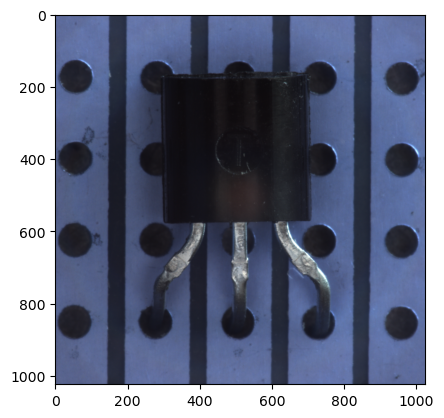

Displaying random defective (bent lead) image from transistor category:
Image randomly chosen: 003.png
Size of image: (1024, 1024, 3)


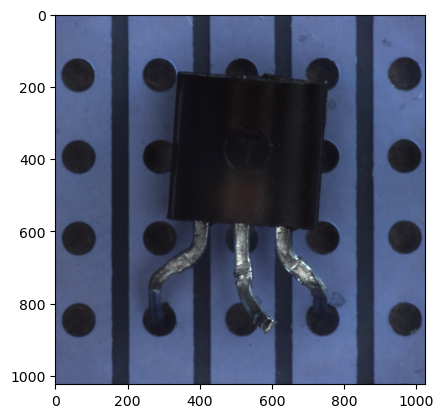

Displaying corresponding ground truth of bent lead defective image:
Image randomly chosen: 003_mask.png
Size of image: (1024, 1024, 3)


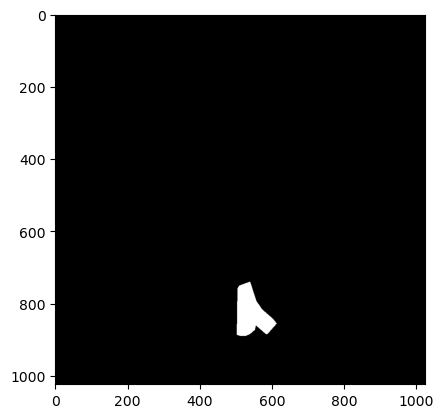

'003_mask.png'

In [6]:
print("Displaying random 'good'/ non-defective image from transistor category:")
img_path = f'{data_location}/transistor/train/good'
display_img(img_path)

print("Displaying random defective (bent lead) image from transistor category:")
img_path = f'{data_location}/transistor/test/bent_lead'
bent_lead_img = display_img(img_path)

print("Displaying corresponding ground truth of bent lead defective image:")
img_path = f'{data_location}/transistor/ground_truth/bent_lead'
mask = x = bent_lead_img.replace(".png", "_mask.png")
display_img(img_path, img=mask)


Displaying random defective (misplaced) image from transistor category:
Image randomly chosen: 001.png
Size of image: (1024, 1024, 3)


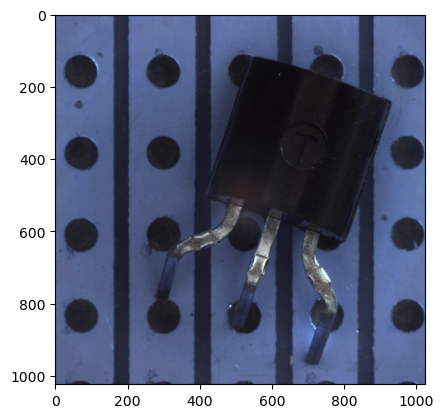

001.png
Displaying corresponding ground truth of bent lead defective image:
Image randomly chosen: 001_mask.png
Size of image: (1024, 1024, 3)


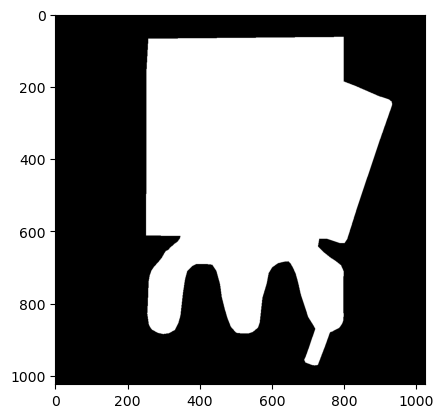

'001_mask.png'

In [113]:
print("Displaying random defective (misplaced) image from transistor category:")
img_path = f'{data_location}/transistor/test/misplaced'
bent_lead_img = display_img(img_path)
print(bent_lead_img)

print("Displaying corresponding ground truth of bent lead defective image:")
img_path = f'{data_location}/transistor/ground_truth/misplaced'
mask = x = bent_lead_img.replace(".png", "_mask.png")
display_img(img_path, img=mask)


## 2. Analysis of class imbalances in dataset

Plots below show large imbalance in classes (good/ train or defect classes)


{'bent_lead': 10, 'cut_lead': 10, 'damaged_case': 10, 'good': 60, 'misplaced': 10, 'train': 213}


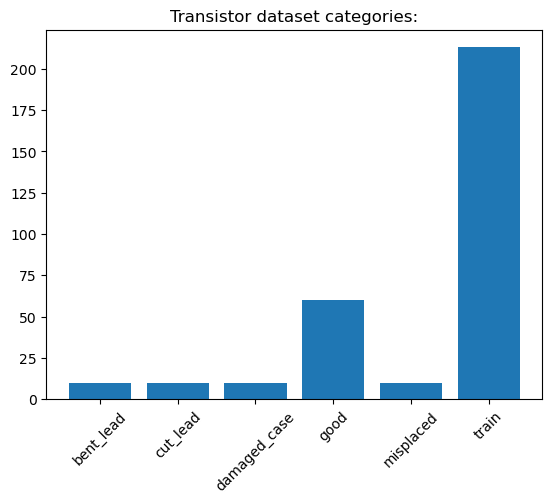

In [114]:
transistor_test_path = f'{data_location}/transistor/test'
imgs_cats_dict = count_img_categories(transistor_test_path, 'png')

transistor_train_path = f'{data_location}/transistor/train/good'
training_size = len([name for name in os.listdir(transistor_train_path) if os.path.isfile(os.path.join(transistor_train_path, name))])
imgs_cats_dict['train'] = training_size
print(imgs_cats_dict)

plt.bar(range(len(imgs_cats_dict)), list(imgs_cats_dict.values()), align='center')
plt.xticks(range(len(imgs_cats_dict)), list(imgs_cats_dict.keys()), rotation=45)
plt.title('Transistor dataset categories:')
plt.show()


{'good': 41, 'manipulated_front': 24, 'scratch_head': 24, 'scratch_neck': 25, 'thread_side': 23, 'thread_top': 23, 'train': 320}


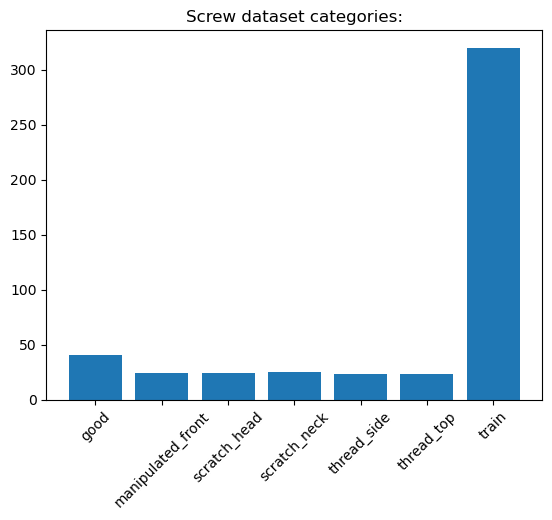

In [115]:
transistor_test_path = f'{data_location}/screw/test'
imgs_cats_dict = count_img_categories(transistor_test_path, 'png')

transistor_train_path = f'{data_location}/screw/train/good'
training_size = len([name for name in os.listdir(transistor_train_path) if os.path.isfile(os.path.join(transistor_train_path, name))])
imgs_cats_dict['train'] = training_size
print(imgs_cats_dict)

plt.bar(range(len(imgs_cats_dict)), list(imgs_cats_dict.values()), align='center')
plt.xticks(range(len(imgs_cats_dict)), list(imgs_cats_dict.keys()), rotation=45)
plt.title('Screw dataset categories:')
plt.show()

## 3. Analysis of mean and standard deviation of different defect categories

Images below show larger variance for certain defect categories than others (large variance for 'misplaced' defect compared to 'bent_lead').

In [34]:
transistor_train_path = f'{data_location}/transistor/train/good'
img_list = os.listdir(transistor_train_path)
#print(img_list)

img_arrays = []
for img in img_list:
    img_arrays.append(cv2.imread(os.path.join(transistor_train_path, img), cv2.IMREAD_GRAYSCALE))

flattened_t = np.array(img_arrays)
print(flattened_t.shape)


(213, 1024, 1024)


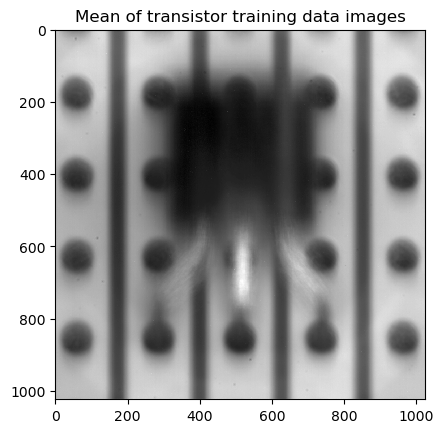

In [35]:
mean_img = flattened_t.mean(axis=0)
plt.imshow(mean_img, cmap='gray', interpolation='None')
plt.title('Mean of transistor training data images')
plt.show()


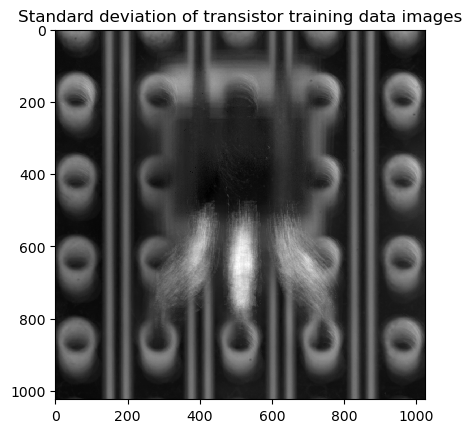

In [36]:
std_img = flattened_t.std(axis=0)
plt.imshow(std_img, cmap='gray', interpolation='None')
plt.title('Standard deviation of transistor training data images')
plt.show()
    

In [41]:
transistor_anomalie_path = f'{data_location}/transistor/test/bent_lead'
img_list = os.listdir(transistor_anomalie_path)
#print(img_list)

img_arrays = []
for img in img_list:
    img_arrays.append(cv2.imread(os.path.join(transistor_anomalie_path, img), cv2.IMREAD_GRAYSCALE))

flattened_b = np.array(img_arrays)
print(flattened.shape)
    

(10, 1024, 1024)


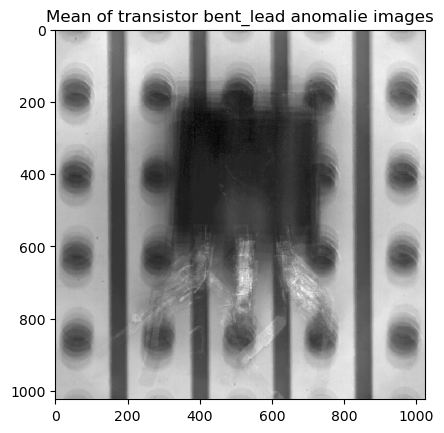

In [42]:
mean_img = flattened_b.mean(axis=0)
plt.imshow(mean_img, cmap='gray', interpolation='None')
plt.title('Mean of transistor bent_lead anomalie images')
plt.show()


In [37]:
transistor_anomalie_path = f'{data_location}/transistor/test/misplaced'
img_list = os.listdir(transistor_anomalie_path)
#print(img_list)

img_arrays = []
for img in img_list:
    img_arrays.append(cv2.imread(os.path.join(transistor_anomalie_path, img), cv2.IMREAD_GRAYSCALE))

flattened_m = np.array(img_arrays)
print(flattened_m.shape)
    

(10, 1024, 1024)


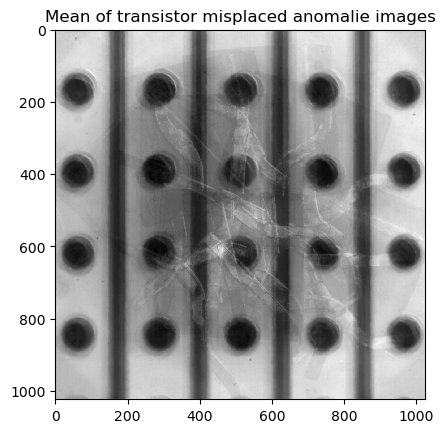

In [40]:
mean_img = flattened_m.mean(axis=0)
plt.imshow(mean_img, cmap='gray', interpolation='None')
plt.title('Mean of transistor misplaced anomalie images')
plt.show()


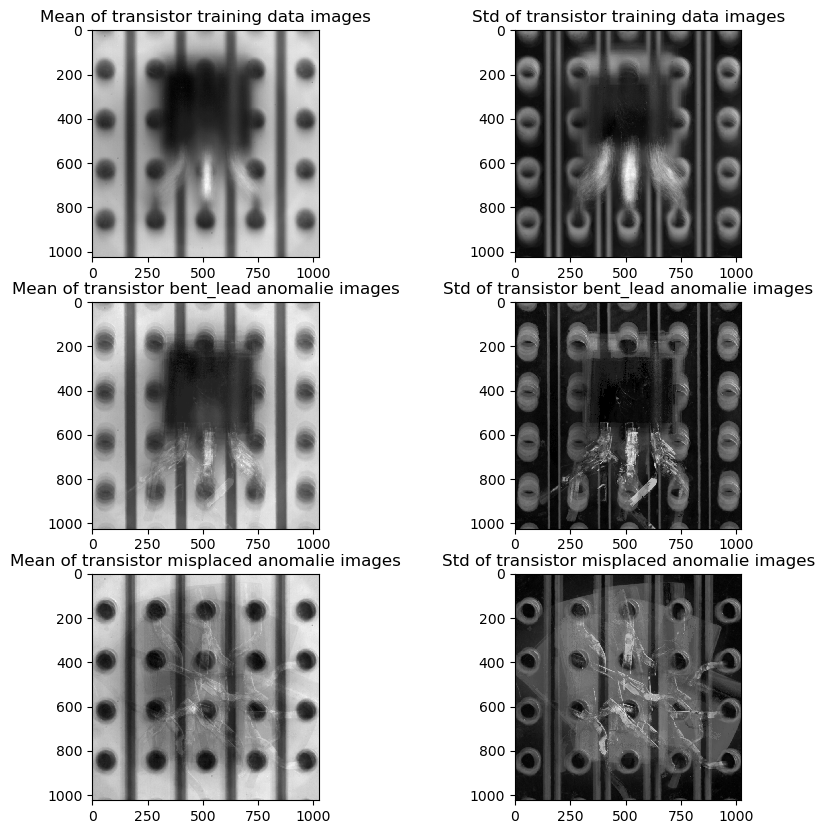

In [49]:
plt.figure(figsize=(10, 10))

plt.subplot(3, 2, 1)
mean_img = flattened_t.mean(axis=0)
plt.imshow(mean_img, cmap='gray', interpolation='None')
plt.title('Mean of transistor training data images')

plt.subplot(3, 2, 2)
std_img = flattened_t.std(axis=0)
plt.imshow(std_img, cmap='gray', interpolation='None')
plt.title('Std of transistor training data images')

plt.subplot(3, 2, 3)
mean_img = flattened_b.mean(axis=0)
plt.imshow(mean_img, cmap='gray', interpolation='None')
plt.title('Mean of transistor bent_lead anomalie images')

plt.subplot(3, 2, 4)
std_img = flattened_b.std(axis=0)
plt.imshow(std_img, cmap='gray', interpolation='None')
plt.title('Std of transistor bent_lead anomalie images')

plt.subplot(3, 2, 5)
mean_img = flattened_m.mean(axis=0)
plt.imshow(mean_img, cmap='gray', interpolation='None')
plt.title('Mean of transistor misplaced anomalie images')

plt.subplot(3, 2, 6)
std_img = flattened_m.std(axis=0)
plt.imshow(std_img, cmap='gray', interpolation='None')
plt.title('Std of transistor misplaced anomalie images')

plt.show()


## 4. More Detailed Analysis of Defect Sizes

Size of defect masks are used to check for outliers for a specific defect type (to then manually check for correct labelling for any outliers detected).

In [ ]:
category = "cable"
mask_dir = f"../Projects/mvtec_anomaly_detection/{category}/ground_truth/bent_wire/"
test_dir = f"../Projects/mvtec_anomaly_detection/{category}/test/bent_wire/"
mask_area_ratios = []
for mask_file in os.listdir(mask_dir):
    mask = cv2.imread(os.path.join(mask_dir, mask_file), cv2.IMREAD_GRAYSCALE)
    mask_area_ratios.append(mask.sum() / (mask.shape[0]*mask.shape[1]))
print(mask_area_ratios)
plt.hist(mask_area_ratios, width=1)
plt.title("Histogram of Defect Area Ratios")
plt.xlabel("Defect Ratio")
plt.ylabel("Count")
plt.show()



ValueError: num must be an integer with 1 <= num <= 9, not 10

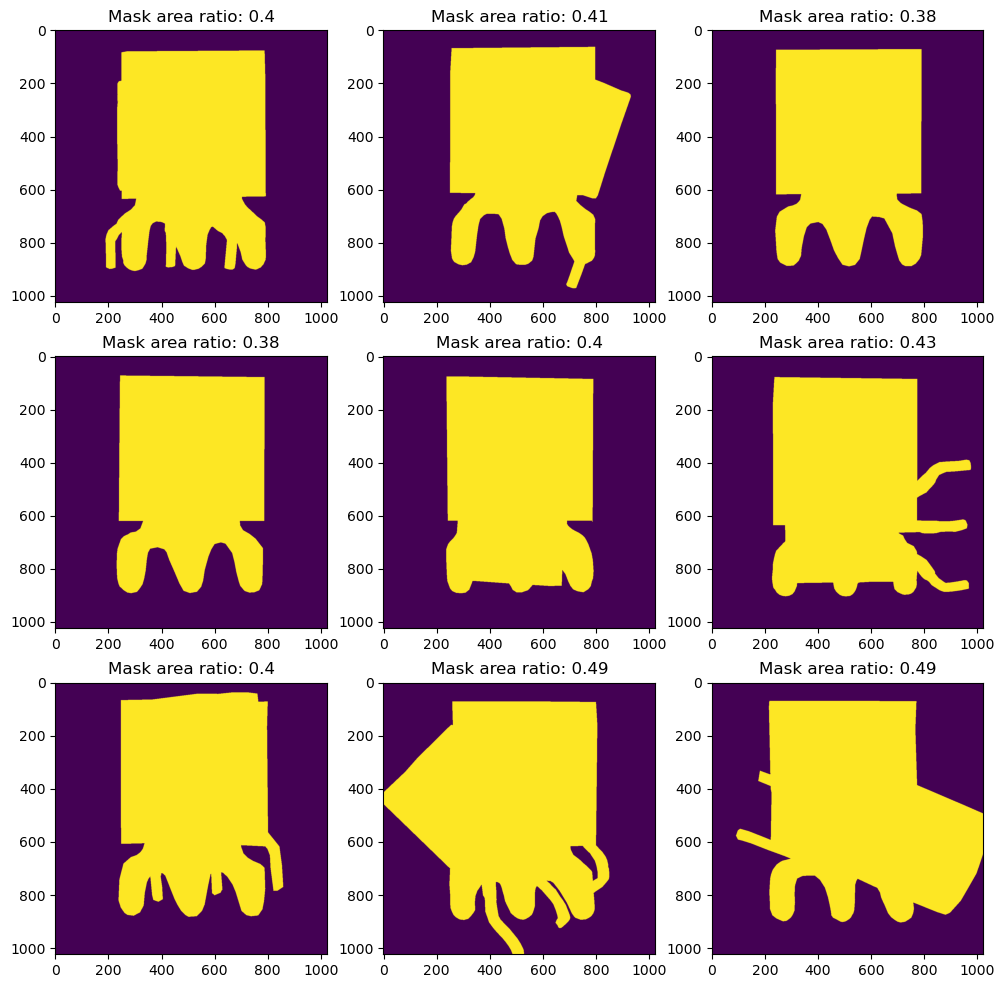

In [22]:
obj = 'transistor'
mask_path = f"{data_location}/{obj}/ground_truth/misplaced"

mask_list = os.listdir(mask_path)
mask_file = random.choice(mask_list)

mask = cv2.imread(os.path.join(mask_path, mask_file), cv2.IMREAD_GRAYSCALE)
#plt.imshow(mask);

#print(mask.sum())
#print(mask.shape[0]*mask.shape[1])
#print(mask.shape)
#print(np.count_nonzero(mask))
#print(mask.shape[0]*mask.shape[1])
#mask_only = np.nonzero(mask)
#print(mask_only)
#print('Non-zero elements divided by total area:')
#print(np.count_nonzero(mask) / (mask.shape[0]*mask.shape[1]))

plt.figure(figsize=(12, 15))
i = 1
for file in mask_list:
    mask = cv2.imread(os.path.join(mask_path, file), cv2.IMREAD_GRAYSCALE)
    #print(mask.shape[0]*mask.shape[1])
    plt.subplot((len(mask_list)//3), 3, i)
    plt.title(f"Mask area ratio: {round(np.count_nonzero(mask) / (mask.shape[0]*mask.shape[1]), 2)}")
    plt.imshow(mask)
    i += 1

plt.show()
    


ValueError: num must be an integer with 1 <= num <= 9, not 10

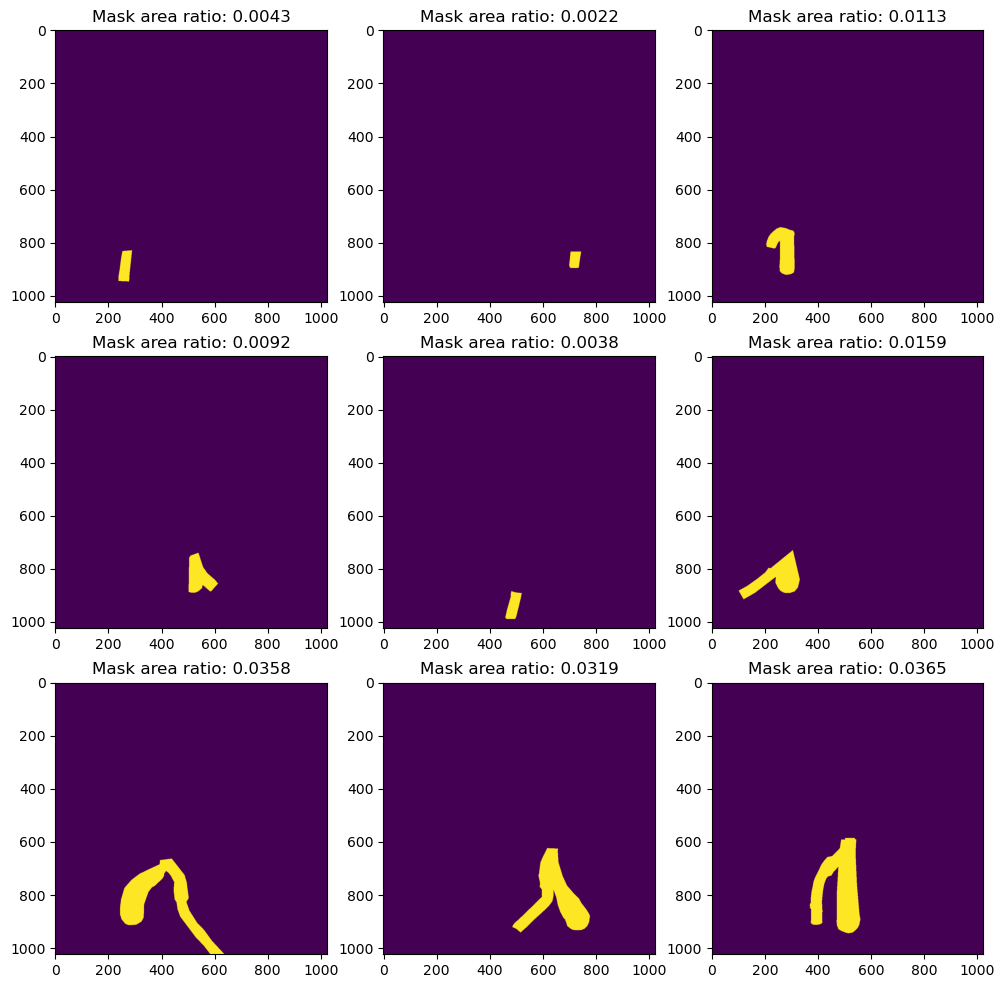

In [26]:
obj = 'transistor'
mask_path = f"{data_location}/{obj}/ground_truth/bent_lead"


def plot_masks_and_ratios(obj, mask_path):
    mask_list = os.listdir(mask_path)
    mask_file = random.choice(mask_list)
    mask = cv2.imread(os.path.join(mask_path, mask_file), cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(12, 12))
    i = 1
    for file in mask_list:
        mask = cv2.imread(os.path.join(mask_path, file), cv2.IMREAD_GRAYSCALE)
        plt.subplot((len(mask_list)//3), 3, i)
        plt.title(f"Mask area ratio: {round(np.count_nonzero(mask) / (mask.shape[0]*mask.shape[1]), 4)}")
        plt.imshow(mask)
        i += 1
    plt.show()

plot_masks_and_ratios(obj, mask_path)


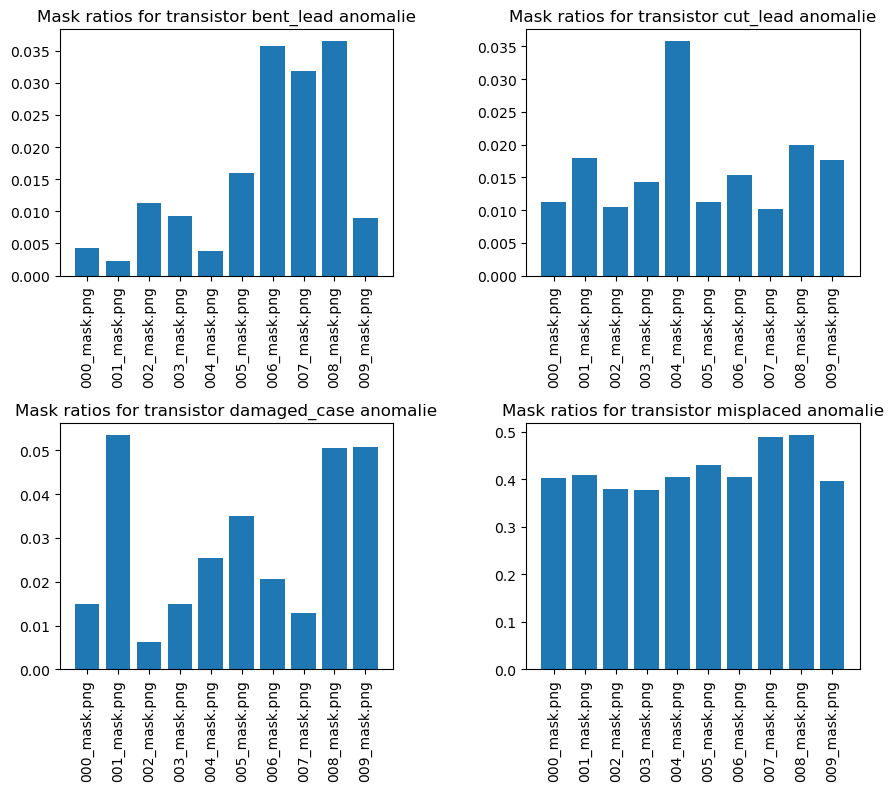

In [7]:
def plot_all_defect_ratios(obj: str, boxplot: bool = False) -> None:
    obj_path = f"{data_location}/{obj}/ground_truth"
    anomalie_list = os.listdir(obj_path)

    plt.figure(figsize=(10, 8))
    i = 1
    for defect in anomalie_list:
        mask_path = os.path.join(obj_path, defect)
        mask_list = os.listdir(mask_path)
    
        mask_ratios = []
        for file in mask_list:
            mask = cv2.imread(os.path.join(mask_path, file), cv2.IMREAD_GRAYSCALE)
            mask_ratios.append(round(np.count_nonzero(mask) / (mask.shape[0]*mask.shape[1]), 4))
        plt.subplot((len(anomalie_list)//2), 2, i)
        plt.title(f"Mask ratios for {obj} {defect} anomalie")
        if boxplot:
            plt.boxplot(mask_ratios)
        else:
            plt.bar(mask_list, mask_ratios)
        plt.xticks(rotation=90)
        i += 1

    plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.4, hspace=0.6)
    plt.show()

plot_all_defect_ratios('transistor')

In [82]:
data_path = f'{data_location}'

all_objects = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
print(all_objects)

#for obj in all_objects:
#    plot_all_defect_ratios(obj)


['metal_nut', 'screw', 'tile', 'transistor', 'bottle', 'cable', 'capsule', 'test', 'carpet', 'grid', 'hazelnut', 'leather', 'pill', 'toothbrush', 'wood', 'zipper']


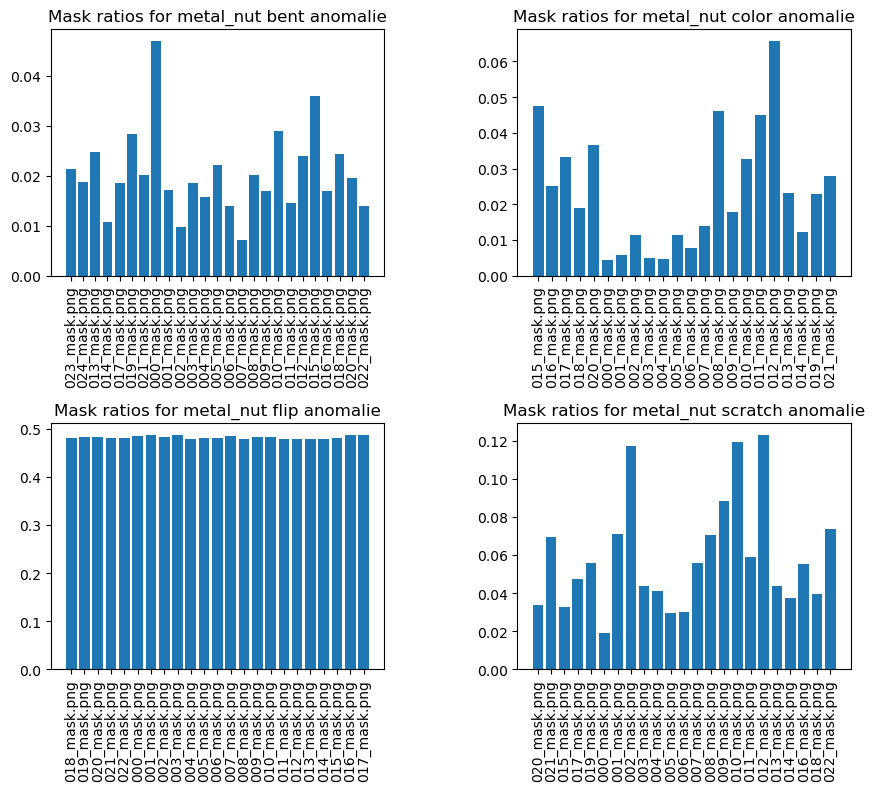

In [83]:
plot_all_defect_ratios('metal_nut')

ValueError: num must be an integer with 1 <= num <= 4, not 5

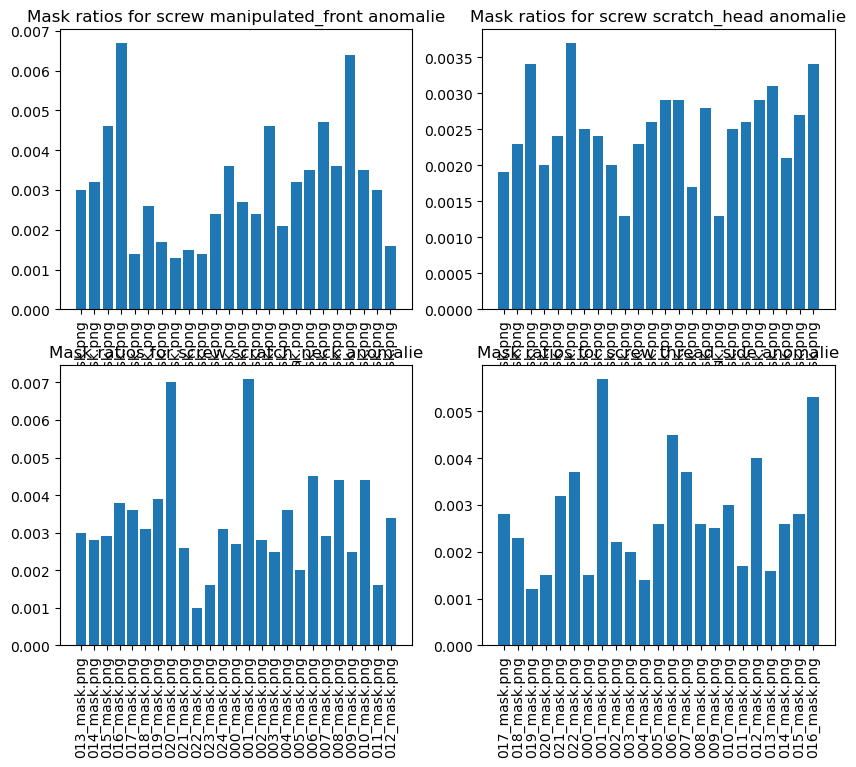

In [84]:
plot_all_defect_ratios('screw')

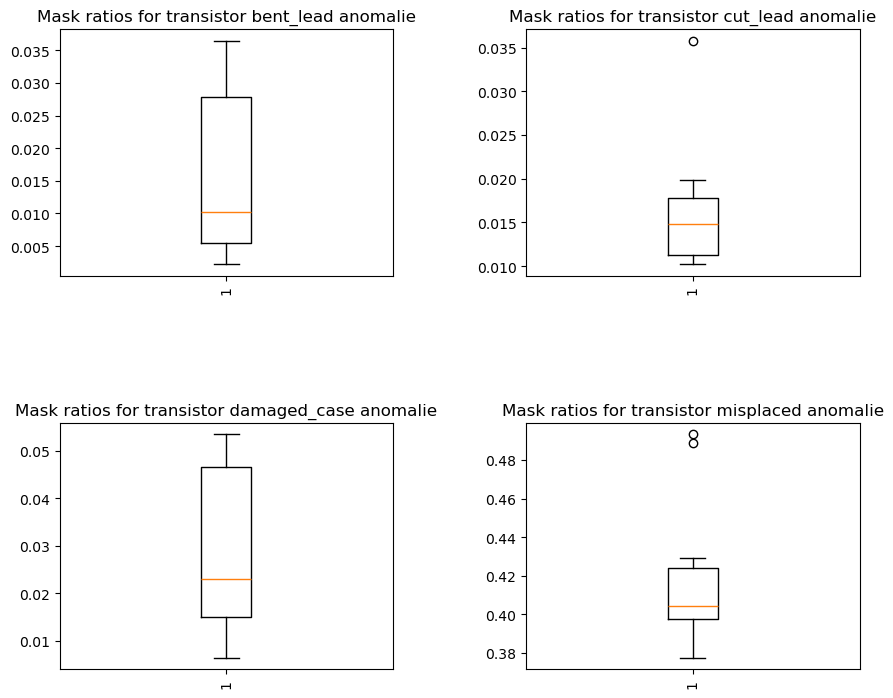

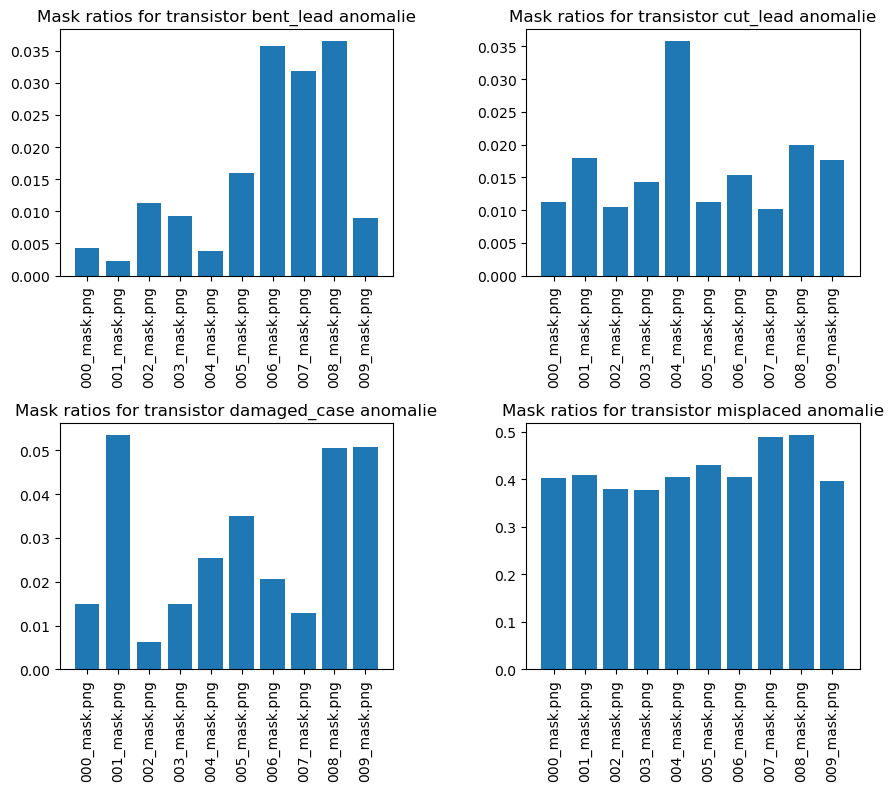

In [9]:

plot_all_defect_ratios('transistor', boxplot=True)
plot_all_defect_ratios('transistor', boxplot=False)



## 5. Comparing pixels to check there are no duplicate images in the dataset
Checks found no duplicates (method was tested by intentionally introducing a duplicate).

In [3]:
def check_for_duplicate_images(obj: str, dataset: str) -> list:
    '''
    Print filenames of any duplicate images found.
    arg dataset is train or test
    '''
    cat_path = f"{data_location}/{obj}/{dataset}"
    dir_list = os.listdir(cat_path)

    all_imgs = []
    for cat in dir_list:
        img_path = os.path.join(cat_path, cat)
        img_list = os.listdir(img_path)
    
        for imgfile in img_list:
            img = cv2.imread(os.path.join(img_path, imgfile), cv2.IMREAD_GRAYSCALE)
            #print(img.shape)
            all_imgs.append(img)

    imgs_stacked_3D = np.dstack(all_imgs)
    shape_all = imgs_stacked_3D.shape
    unique_imgs = np.unique(imgs_stacked_3D, axis=2)
    shape_unique = unique_imgs.shape
    if (shape_unique == shape_all):
        print('All image arrays are unique')
    else:
        duplicate_imgs = imgs_stacked_3D - unique_imgs
        print('Some duplicates image arrays have been found:')
        print(duplicate_imgs)

    return imgs_stacked_3D

imgs_array = check_for_duplicate_images('transistor', 'test')


All image arrays are unique


In [4]:
print(imgs_array.shape)
test_imgs_array = imgs_array
train_imgs_array = check_for_duplicate_images('transistor', 'train')


(1024, 1024, 100)
All image arrays are unique


In [5]:
print(train_imgs_array.shape)
imgs_stacked_3D = np.concatenate([test_imgs_array, train_imgs_array], -1)
print(imgs_stacked_3D.shape)
unique_imgs = np.unique(imgs_stacked_3D, axis=2)
print('Train and test images are all unique?:')
print(imgs_stacked_3D.shape == unique_imgs.shape)

(1024, 1024, 213)
(1024, 1024, 313)
Train and test images are all unique?:
True


In [13]:
data_path = f'{data_location}'
all_objects = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
print(f'Checking for duplicate images in object categories:\n {all_objects}\n')

all_in_cat_unique = []
for obj in all_objects:
    print(f'\n Checking for duplicates in train images for {obj}')
    train_imgs_array = check_for_duplicate_images(obj, 'train')
    print(f'Checking for duplicates in test images for {obj}')
    test_imgs_array = check_for_duplicate_images(obj, 'test')
    imgs_stacked_3D = np.concatenate([test_imgs_array, train_imgs_array], -1)
    unique_imgs = np.unique(imgs_stacked_3D, axis=2)
    print('Checking there are no duplicates between train and test sets:')
    print(imgs_stacked_3D.shape == unique_imgs.shape)
    all_in_cat_unique.append(imgs_stacked_3D.shape == unique_imgs.shape)

print('\n Confirming no duplicates found for any category:')
print(set(all_in_cat_unique))



Checking for duplicate images in object categories:
 ['metal_nut', 'screw', 'tile', 'transistor', 'bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'pill', 'toothbrush', 'wood', 'zipper']


 Checking for duplicates in train images for metal_nut
All image arrays are unique
Checking for duplicates in test images for metal_nut
All image arrays are unique
Checking there are no duplicates between train and test sets:
True

 Checking for duplicates in train images for screw
All image arrays are unique
Checking for duplicates in test images for screw
All image arrays are unique
Checking there are no duplicates between train and test sets:
True

 Checking for duplicates in train images for tile
All image arrays are unique
Checking for duplicates in test images for tile
All image arrays are unique
Checking there are no duplicates between train and test sets:
True

 Checking for duplicates in train images for transistor
All image arrays are unique
Checking for duplicates in 

In [10]:
# Check function used above with data where I have intentionally put a duplicate image

with_duplicate_test_arrays = check_for_duplicate_images('function_test', 'misc_cable_imgs')


1 duplicates image arrays have been found.


## 6. Further investigations: visualising colour channels, PCA for defect classes, Laplacian to check image blurriness

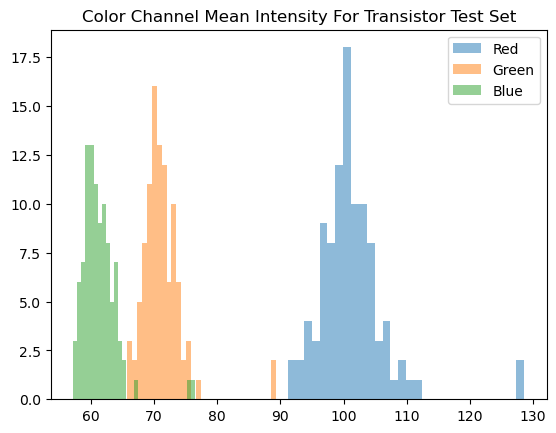

In [12]:
# Colour analysis (to check for dominant colour channels)
# See: https://palospublishing.com/how-to-perform-exploratory-data-analysis-on-image-data/

from PIL import Image

data_dir = f'{data_location}/transistor/test'
classes = ['bent_lead', 'cut_lead', 'damaged_case', 'good', 'misplaced']

r_means, g_means, b_means = [], [], []

for cls in classes:
    folder = os.path.join(data_dir, cls)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path).convert('RGB')
        img_array = np.array(img)
        r_means.append(np.mean(img_array[:,:,0]))
        g_means.append(np.mean(img_array[:,:,1]))
        b_means.append(np.mean(img_array[:,:,2]))

plt.hist(r_means, bins=30, alpha=0.5, label='Red')
plt.hist(g_means, bins=30, alpha=0.5, label='Green')
plt.hist(b_means, bins=30, alpha=0.5, label='Blue')
plt.legend()
plt.title("Color Channel Mean Intensity For Transistor Test Set")
plt.show()



In [ ]:
from PIL import Image

data_dir = f'{data_location}/transistor/test'
classes = ['bent_lead', 'cut_lead', 'damaged_case', 'good', 'misplaced']

r_means, g_means, b_means = [], [], []

for cls in classes:
    folder = os.path.join(data_dir, cls)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path).convert('RGB')
        img_array = np.array(img)
        r_means.append(np.mean(img_array[:,:,0]))
        g_means.append(np.mean(img_array[:,:,1]))
        b_means.append(np.mean(img_array[:,:,2]))

plt.hist(r_means, bins=30, alpha=0.5, label='Red')
plt.hist(g_means, bins=30, alpha=0.5, label='Green')
plt.hist(b_means, bins=30, alpha=0.5, label='Blue')
plt.legend()
plt.title("Color Channel Mean Intensity For Transistor Test Set")
plt.show()



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


2026-01-04 14:49:11.564718: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 12845056 exceeds 10% of free system memory.
2026-01-04 14:49:11.581720: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 12845056 exceeds 10% of free system memory.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 966ms/step


2026-01-04 14:49:12.326771: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 12845056 exceeds 10% of free system memory.
2026-01-04 14:49:12.339708: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 12845056 exceeds 10% of free system memory.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step


2026-01-04 14:49:13.135359: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 12845056 exceeds 10% of free system memory.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 738ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 897ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 757ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

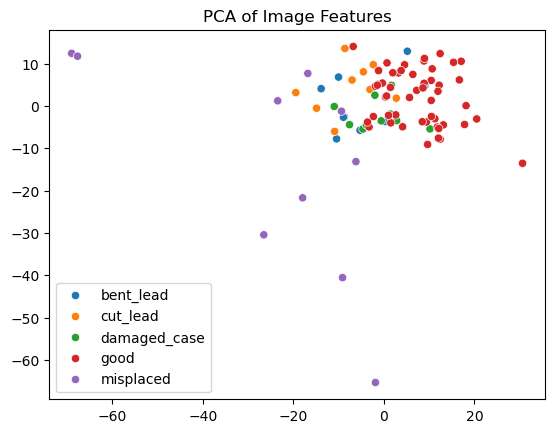

In [5]:
# Visualise data cluster to check for overlap in classes, outliers, or noise
# See: https://palospublishing.com/how-to-perform-exploratory-data-analysis-on-image-data/

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.decomposition import PCA
import seaborn as sns


data_dir = f'{data_location}/transistor/test'
classes = ['bent_lead', 'cut_lead', 'damaged_case', 'good', 'misplaced']


model = VGG16(include_top=False, input_shape=(224,224,3), pooling='avg')

features = []
labels = []

for cls in classes:
    folder = os.path.join(data_dir, cls)
    for img_name in os.listdir(folder)[:50]:  # Sample for speed
        img_path = os.path.join(folder, img_name)
        img = load_img(img_path, target_size=(224,224))
        x = img_to_array(img)
        x = preprocess_input(x)
        x = np.expand_dims(x, axis=0)
        feat = model.predict(x)
        features.append(feat.flatten())
        labels.append(cls)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=labels)
plt.title("PCA of Image Features")
plt.show()


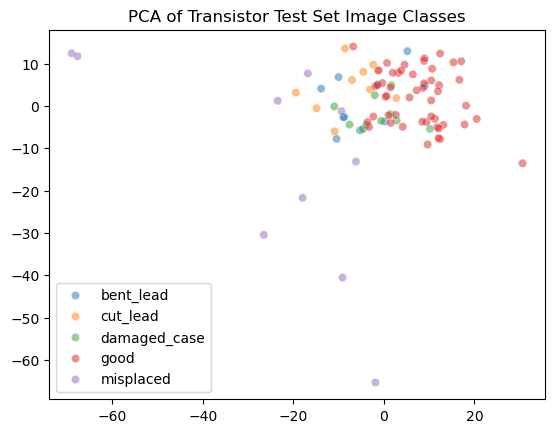

In [9]:
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=labels, alpha=0.5)
plt.title("PCA of Transistor Test Set Image Classes")
plt.show()

In [24]:
# Assessing if images are blurry
# See: https://www.geeksforgeeks.org/computer-vision/how-to-check-for-blurry-images-in-your-dataset-using-the-laplacian-method/

def is_blurry(image, threshold=100.0):
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Compute the Laplacian of the image and then the variance
    laplacian_var = cv2.Laplacian(gray_image, cv2.CV_64F).var()

    return float(laplacian_var)

img_dir = f'{data_location}/metal_nut/test/bent'
imgs = os.listdir(img_dir)

laplacians = []
for img in imgs:
    img_path = os.path.join(img_dir, img)
    image = cv2.imread(img_path)
    laplacians.append(is_blurry(image))


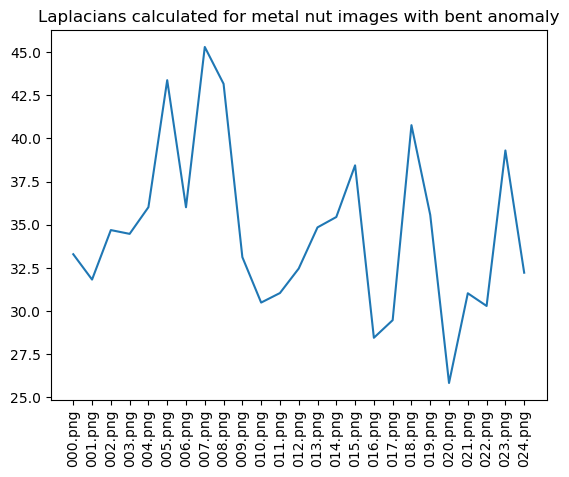

In [26]:
plt.plot(imgs, laplacians)
plt.title('Laplacians calculated for metal nut images with bent anomaly')
plt.xticks(rotation=90)
plt.show()


In [30]:
defect = 'bent'
img_dir = f'{data_location}/metal_nut/test/{defect}'
imgs = os.listdir(img_dir)

laplacians_bent = []
for img in imgs:
    img_path = os.path.join(img_dir, img)
    image = cv2.imread(img_path)
    laplacians_bent.append(is_blurry(image))


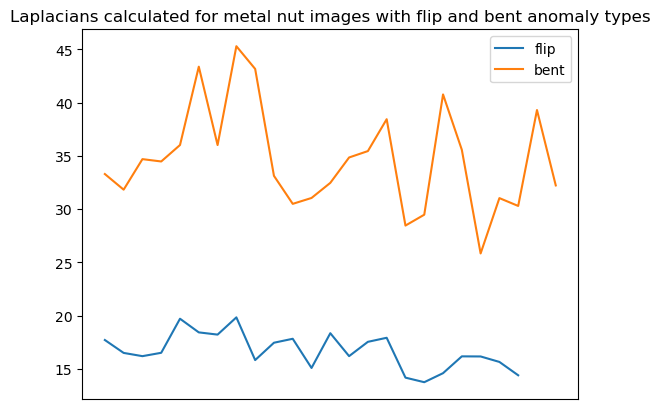

In [33]:
defect = 'flip'
img_dir = f'{data_location}/metal_nut/test/{defect}'
imgs = os.listdir(img_dir)

laplacians_flip = []
for img in imgs:
    img_path = os.path.join(img_dir, img)
    image = cv2.imread(img_path)
    laplacians_flip.append(is_blurry(image))

plt.plot(laplacians_flip, label='flip')
plt.plot(laplacians_bent, label='bent')
plt.title(f'Laplacians calculated for metal nut images with flip and bent anomaly types')
plt.legend()
plt.xticks([])
plt.show()